In [8]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configuration variable
NHNN = False  # Set to False to exclude cases with 'NHNN' in case_id

# Set style for better plots
plt.style.use('default')
sns.set_palette("husl")

# Load the JSON files
segresnet_path = "/home/jruffle/Documents/seq-synth/enhancement_predictor/segresnet_v3_janga_no_drop/final_bin_predictions/summary.json"
nnunet_path = "/home/jruffle/Documents/nnUNet/nnUNet_raw/Dataset001_enhance/predictionsTs_PP/summary.json"
dataset002_path = "/media/jruffle/DATA/nnUNet/nnUNet_raw/Dataset002_enhance_and_abnormality/predictionsTs_PP/summary.json"

# Load SegResNet results
with open(segresnet_path, 'r') as f:
    segresnet_data = json.load(f)

# Load nnUNet Dataset001 results  
with open(nnunet_path, 'r') as f:
    nnunet_data = json.load(f)

# Load Dataset002 results
with open(dataset002_path, 'r') as f:
    dataset002_data = json.load(f)

print("Files loaded successfully!")
print(f"NHNN filtering: {'Enabled (all cases)' if NHNN else 'Disabled (excluding NHNN cases)'}")
print(f"SegResNet mean metrics: {segresnet_data['foreground_mean']}")
print(f"nnUNet Dataset001 mean metrics: {nnunet_data['foreground_mean']}")
print(f"Dataset002 class 3 (enhancement) metrics: {dataset002_data['mean']['3']}")
print(f"\nDataset002 has classes: {list(dataset002_data['mean'].keys())}")
print("Using class 3 for enhancement comparison")

Files loaded successfully!
NHNN filtering: Disabled (excluding NHNN cases)
SegResNet mean metrics: {'Dice': 0.36854456200551056, 'FN': 1915.0495942290352, 'FP': 29283.167718665463, 'IoU': 0.2636386413831116, 'TN': 7174165.602344454, 'TP': 15668.180342651038, 'n_pred': 44951.3480613165, 'n_ref': 17583.22993688007}
nnUNet Dataset001 mean metrics: {'Dice': 0.5232184697144336, 'FN': 4107.411181244364, 'FP': 5197.710550045085, 'IoU': 0.4172513059381037, 'TN': 7198251.059513075, 'TP': 13475.818755635708, 'n_pred': 18673.529305680793, 'n_ref': 17583.22993688007}
Dataset002 class 3 (enhancement) metrics: {'Dice': 0.5326000130985554, 'FN': 4609.860234445447, 'FP': 4189.450856627593, 'IoU': 0.4248432700476577, 'TN': 7199259.319206492, 'TP': 12973.369702434626, 'n_pred': 17162.820559062216, 'n_ref': 17583.22993688007}

Dataset002 has classes: ['1', '2', '3']
Using class 3 for enhancement comparison


In [ ]:
# Extract per-case metrics for more detailed analysis (now with 3 models and NHNN filtering)
def extract_per_case_metrics(data, model_name, class_id='1'):
    """Extract per-case metrics from the JSON data"""
    cases = []
    for case in data['metric_per_case']:
        if class_id in case['metrics']:  # Check if metrics exist for the specified class
            metrics = case['metrics'][class_id]
            # Handle NaN values
            dice = metrics['Dice'] if not (isinstance(metrics['Dice'], float) and np.isnan(metrics['Dice'])) else 0
            iou = metrics['IoU'] if not (isinstance(metrics['IoU'], float) and np.isnan(metrics['IoU'])) else 0
            
            case_id = case['prediction_file'].split('/')[-1].replace('.nii.gz', '')
            
            cases.append({
                'model': model_name,
                'case_id': case_id,
                'dice': dice,
                'iou': iou,
                'tp': metrics['TP'],
                'fp': metrics['FP'],
                'fn': metrics['FN'],
                'tn': metrics['TN'],
                'n_pred': metrics['n_pred'],
                'n_ref': metrics['n_ref']
            })
    return cases

# Extract per-case data for all 3 models
segresnet_cases = extract_per_case_metrics(segresnet_data, 'SegResNet')
nnunet_cases = extract_per_case_metrics(nnunet_data, 'nnUNet_Dataset001')
dataset002_cases = extract_per_case_metrics(dataset002_data, 'Dataset002_enhance_and_abnormality', class_id='3')

# Combine into single dataframe
all_cases = pd.DataFrame(segresnet_cases + nnunet_cases + dataset002_cases)

# Apply NHNN filtering if needed
if not NHNN:
    # Filter out cases containing 'NHNN' in case_id
    original_count = len(all_cases)
    all_cases = all_cases[~all_cases['case_id'].str.contains('NHNN', na=False)]
    filtered_count = len(all_cases)
    print(f"NHNN filtering applied: {original_count} -> {filtered_count} cases (removed {original_count - filtered_count} NHNN cases)")
else:
    print("NHNN filtering disabled: using all cases")

# Count cases per model after filtering
segresnet_count = len(all_cases[all_cases['model'] == 'SegResNet'])
nnunet_count = len(all_cases[all_cases['model'] == 'nnUNet_Dataset001'])
dataset002_count = len(all_cases[all_cases['model'] == 'Dataset002_enhance_and_abnormality'])

print(f"\nTotal cases analyzed (after filtering):")
print(f"  SegResNet: {segresnet_count}")
print(f"  nnUNet Dataset001: {nnunet_count}")
print(f"  Dataset002 (class 3): {dataset002_count}")
print(f"\nFirst few rows of combined data:")
print(all_cases.head())

In [ ]:
# Calculate filtered metrics and create comparison
def calculate_filtered_metrics(all_cases_df, model_name):
    """Calculate metrics for filtered dataset"""
    model_data = all_cases_df[all_cases_df['model'] == model_name]
    
    if len(model_data) == 0:
        return {
            'Dice': 0, 'IoU': 0, 'TP': 0, 'FP': 0, 'FN': 0, 'TN': 0, 
            'n_pred': 0, 'n_ref': 0
        }
    
    return {
        'Dice': model_data['dice'].mean(),
        'IoU': model_data['iou'].mean(),
        'TP': model_data['tp'].mean(),
        'FP': model_data['fp'].mean(),
        'FN': model_data['fn'].mean(),
        'TN': model_data['tn'].mean(),
        'n_pred': model_data['n_pred'].mean(),
        'n_ref': model_data['n_ref'].mean()
    }

# Calculate metrics based on filtering setting
if NHNN:
    # Use original JSON metrics (all cases)
    segresnet_metrics = segresnet_data['foreground_mean']
    nnunet_metrics = nnunet_data['foreground_mean']
    dataset002_metrics = dataset002_data['mean']['3']
    print("Using original JSON metrics (all cases)")
else:
    # Calculate metrics from filtered per-case data (excluding NHNN cases)
    segresnet_metrics = calculate_filtered_metrics(all_cases, 'SegResNet')
    nnunet_metrics = calculate_filtered_metrics(all_cases, 'nnUNet_Dataset001')
    dataset002_metrics = calculate_filtered_metrics(all_cases, 'Dataset002_enhance_and_abnormality')
    print("Using filtered metrics (excluding NHNN cases)")

# Create comparison dataframe
metrics_comparison = pd.DataFrame({
    'SegResNet': segresnet_metrics,
    'nnUNet_Dataset001': nnunet_metrics,
    'Dataset002_enhance_and_abnormality': dataset002_metrics
}).T

print("\nOverall Metrics Comparison:")
print(metrics_comparison.round(4))

# Determine which model performed better
print("\n" + "="*60)
print("MODEL PERFORMANCE COMPARISON (3 MODELS)")
print("="*60)

# Key metrics for comparison
key_metrics = ['Dice', 'IoU']
models = {
    'SegResNet': segresnet_metrics,
    'nnUNet_Dataset001': nnunet_metrics, 
    'Dataset002_enhance_and_abnormality': dataset002_metrics
}

for metric in key_metrics:
    print(f"\n{metric} Scores:")
    metric_values = []
    for model_name, model_data in models.items():
        value = model_data[metric]
        metric_values.append((model_name, value))
        print(f"  {model_name:30}: {value:.4f}")
    
    # Find the best performing model for this metric
    best_model = max(metric_values, key=lambda x: x[1])
    print(f"  {'WINNER':30}: {best_model[0]} ({best_model[1]:.4f})")

# Overall winner based on Dice score
dice_scores = [(name, data['Dice']) for name, data in models.items()]
overall_winner = max(dice_scores, key=lambda x: x[1])

print(f"\n{'='*60}")
print(f"OVERALL WINNER: {overall_winner[0]} (Dice: {overall_winner[1]:.4f})")
print(f"{'='*60}")

# Show improvement comparisons
segresnet_dice = segresnet_metrics['Dice']
dataset001_dice = nnunet_metrics['Dice']
dataset002_dice = dataset002_metrics['Dice']

print(f"\nPerformance improvements:")
print(f"  Dataset001 vs SegResNet: +{dataset001_dice - segresnet_dice:.4f} ({((dataset001_dice / segresnet_dice - 1) * 100):+.1f}%)")
print(f"  Dataset002 vs SegResNet: +{dataset002_dice - segresnet_dice:.4f} ({((dataset002_dice / segresnet_dice - 1) * 100):+.1f}%)")
print(f"  Dataset002 vs Dataset001: +{dataset002_dice - dataset001_dice:.4f} ({((dataset002_dice / dataset001_dice - 1) * 100):+.1f}%)")

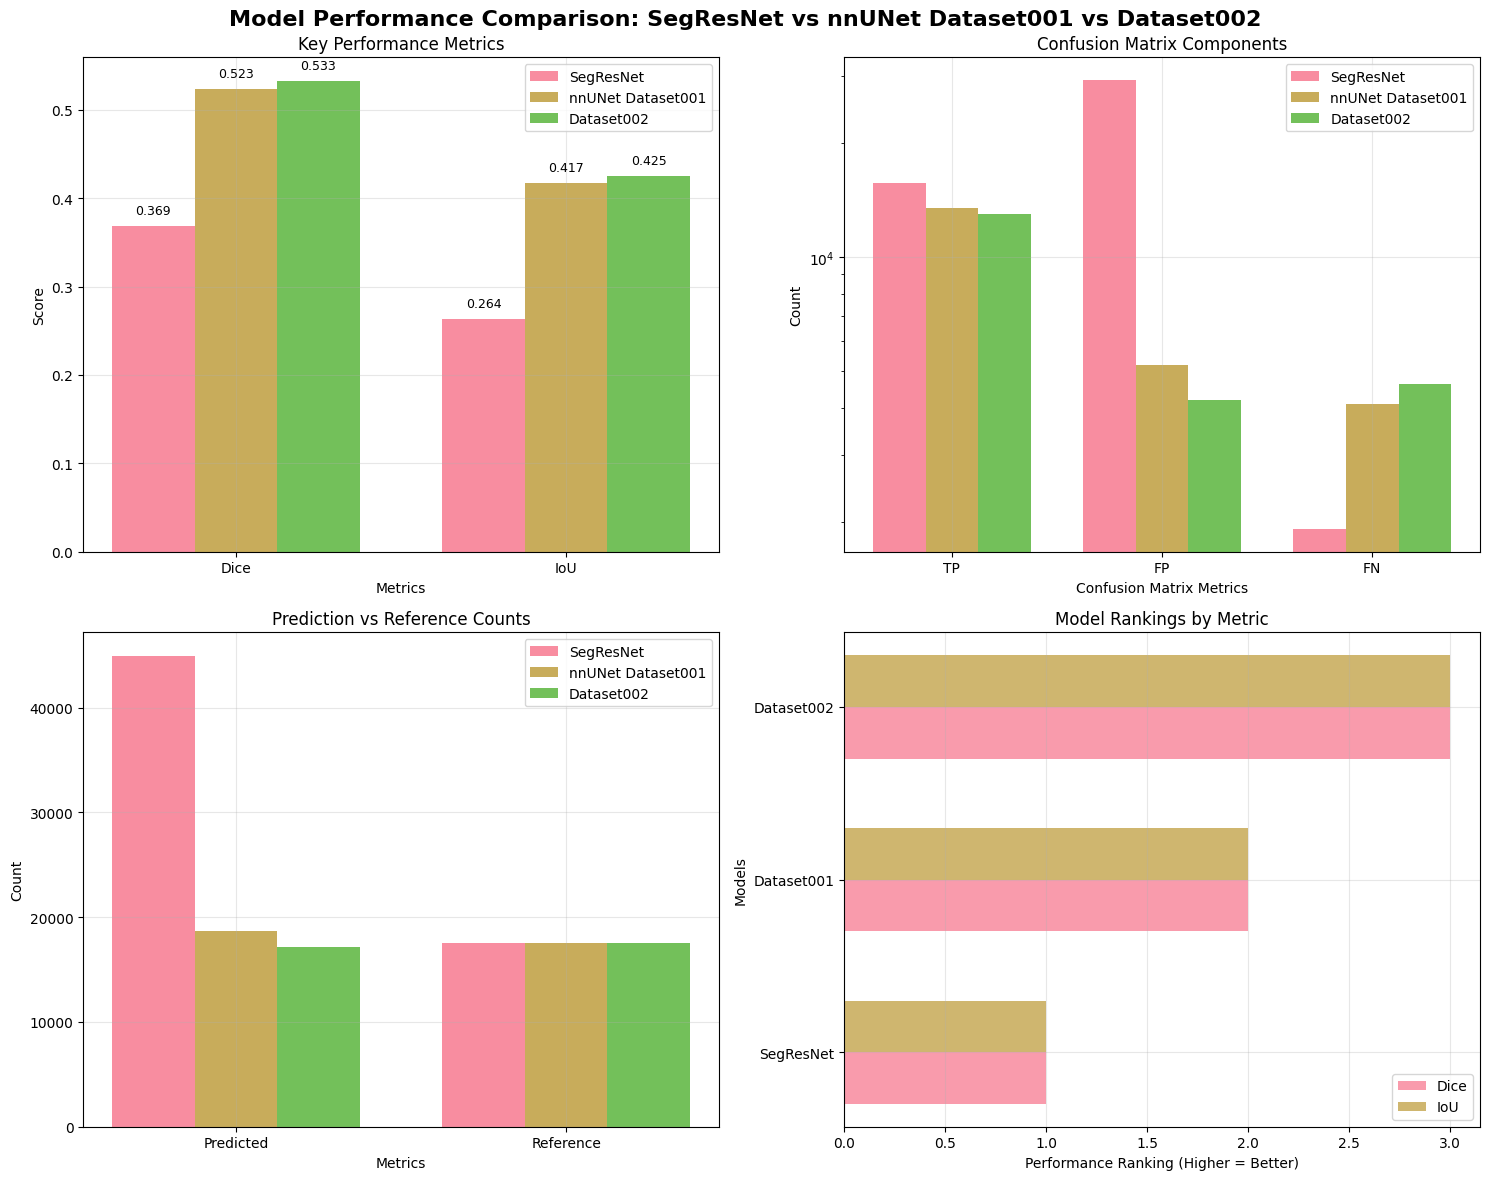

In [10]:
# Create visualizations comparing the 3 models
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Model Performance Comparison: SegResNet vs nnUNet Dataset001 vs Dataset002', fontsize=16, fontweight='bold')

# 1. Bar plot for key metrics
key_metrics = ['Dice', 'IoU']
models = ['SegResNet', 'nnUNet_Dataset001', 'Dataset002_enhance_and_abnormality']
x_pos = np.arange(len(key_metrics))

segresnet_values = [segresnet_data['foreground_mean'][m] for m in key_metrics]
nnunet_values = [nnunet_data['foreground_mean'][m] for m in key_metrics]
dataset002_values = [dataset002_data['mean']['3'][m] for m in key_metrics]

width = 0.25
axes[0,0].bar(x_pos - width, segresnet_values, width, label='SegResNet', alpha=0.8)
axes[0,0].bar(x_pos, nnunet_values, width, label='nnUNet Dataset001', alpha=0.8)
axes[0,0].bar(x_pos + width, dataset002_values, width, label='Dataset002', alpha=0.8)

axes[0,0].set_xlabel('Metrics')
axes[0,0].set_ylabel('Score')
axes[0,0].set_title('Key Performance Metrics')
axes[0,0].set_xticks(x_pos)
axes[0,0].set_xticklabels(key_metrics)
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Add value labels on bars
for i, (seg_val, nn_val, d002_val) in enumerate(zip(segresnet_values, nnunet_values, dataset002_values)):
    axes[0,0].text(i - width, seg_val + 0.01, f'{seg_val:.3f}', ha='center', va='bottom', fontsize=9)
    axes[0,0].text(i, nn_val + 0.01, f'{nn_val:.3f}', ha='center', va='bottom', fontsize=9)
    axes[0,0].text(i + width, d002_val + 0.01, f'{d002_val:.3f}', ha='center', va='bottom', fontsize=9)

# 2. Confusion matrix related metrics
conf_metrics = ['TP', 'FP', 'FN']
segresnet_conf = [segresnet_data['foreground_mean'][m] for m in conf_metrics]
nnunet_conf = [nnunet_data['foreground_mean'][m] for m in conf_metrics]
dataset002_conf = [dataset002_data['mean']['3'][m] for m in conf_metrics]

x_pos_conf = np.arange(len(conf_metrics))
axes[0,1].bar(x_pos_conf - width, segresnet_conf, width, label='SegResNet', alpha=0.8)
axes[0,1].bar(x_pos_conf, nnunet_conf, width, label='nnUNet Dataset001', alpha=0.8)
axes[0,1].bar(x_pos_conf + width, dataset002_conf, width, label='Dataset002', alpha=0.8)

axes[0,1].set_xlabel('Confusion Matrix Metrics')
axes[0,1].set_ylabel('Count')
axes[0,1].set_title('Confusion Matrix Components')
axes[0,1].set_xticks(x_pos_conf)
axes[0,1].set_xticklabels(conf_metrics)
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)
axes[0,1].set_yscale('log')  # Log scale due to large differences

# 3. Prediction vs Reference counts
pred_ref_metrics = ['n_pred', 'n_ref']
segresnet_pred_ref = [segresnet_data['foreground_mean'][m] for m in pred_ref_metrics]
nnunet_pred_ref = [nnunet_data['foreground_mean'][m] for m in pred_ref_metrics]
dataset002_pred_ref = [dataset002_data['mean']['3'][m] for m in pred_ref_metrics]

x_pos_pr = np.arange(len(pred_ref_metrics))
axes[1,0].bar(x_pos_pr - width, segresnet_pred_ref, width, label='SegResNet', alpha=0.8)
axes[1,0].bar(x_pos_pr, nnunet_pred_ref, width, label='nnUNet Dataset001', alpha=0.8)
axes[1,0].bar(x_pos_pr + width, dataset002_pred_ref, width, label='Dataset002', alpha=0.8)

axes[1,0].set_xlabel('Metrics')
axes[1,0].set_ylabel('Count')
axes[1,0].set_title('Prediction vs Reference Counts')
axes[1,0].set_xticks(x_pos_pr)
axes[1,0].set_xticklabels(['Predicted', 'Reference'])
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# 4. Performance ranking visualization
metrics_for_ranking = ['Dice', 'IoU']
model_names = ['SegResNet', 'Dataset001', 'Dataset002']
colors = ['#ff7f0e', '#2ca02c', '#1f77b4']

# Create a ranking table visualization
ranking_data = []
for metric in metrics_for_ranking:
    values = [
        segresnet_data['foreground_mean'][metric],
        nnunet_data['foreground_mean'][metric], 
        dataset002_data['mean']['3'][metric]
    ]
    # Sort by value (descending) and get ranks
    sorted_indices = sorted(range(len(values)), key=lambda i: values[i], reverse=True)
    ranks = [0] * len(values)
    for rank, idx in enumerate(sorted_indices):
        ranks[idx] = rank + 1
    ranking_data.append(ranks)

# Plot ranking as horizontal bars
y_pos = np.arange(len(model_names))
for i, metric in enumerate(metrics_for_ranking):
    offset = (i - 0.5) * 0.3
    ranks = ranking_data[i]
    axes[1,1].barh(y_pos + offset, [4-r for r in ranks], height=0.3, 
                   label=metric, alpha=0.7)

axes[1,1].set_xlabel('Performance Ranking (Higher = Better)')
axes[1,1].set_ylabel('Models')
axes[1,1].set_title('Model Rankings by Metric')
axes[1,1].set_yticks(y_pos)
axes[1,1].set_yticklabels(model_names)
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

/tmp/ipykernel_437165/614440556.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0,0].boxplot([all_cases[all_cases['model'] == 'SegResNet']['dice'],
/tmp/ipykernel_437165/614440556.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0,1].boxplot([all_cases[all_cases['model'] == 'SegResNet']['iou'],
/home/jruffle/.local/lib/python3.10/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


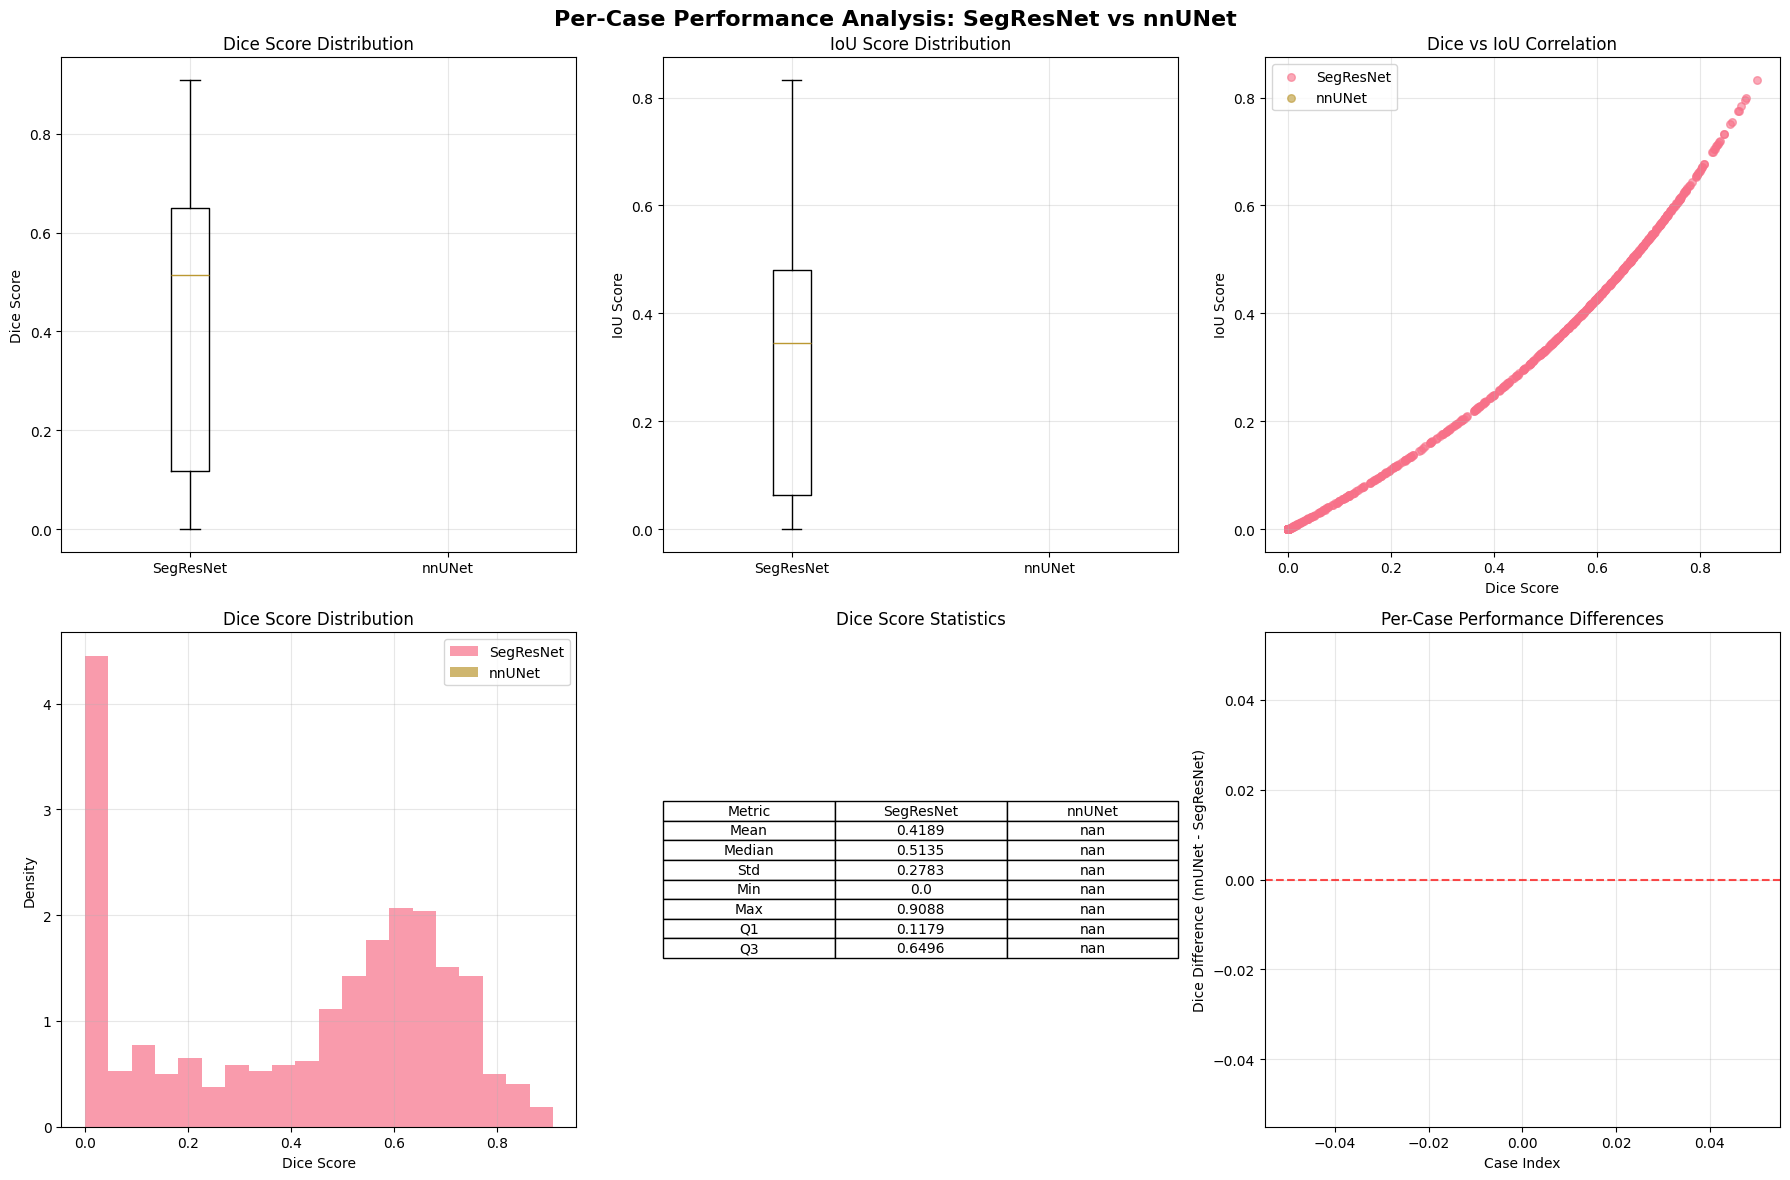


DETAILED PERFORMANCE SUMMARY

Dice Score Statistics:
SegResNet - Mean: 0.4189 ± 0.2783
nnUNet    - Mean: nan ± nan

Cases where nnUNet > SegResNet: 0/0
Cases where SegResNet > nnUNet: 0/0
Cases with no difference: 0/0

Top 5 cases where nnUNet outperformed SegResNet:
Empty DataFrame
Columns: [dice_seg, dice_nn, dice_diff]
Index: []

Top 5 cases where SegResNet outperformed nnUNet:
Empty DataFrame
Columns: [dice_seg, dice_nn, dice_diff]
Index: []


In [13]:
# Create detailed per-case comparison visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Per-Case Performance Analysis: SegResNet vs nnUNet', fontsize=16, fontweight='bold')

# 1. Box plots for Dice scores
axes[0,0].boxplot([all_cases[all_cases['model'] == 'SegResNet']['dice'], 
                   all_cases[all_cases['model'] == 'nnUNet']['dice']], 
                  labels=['SegResNet', 'nnUNet'])
axes[0,0].set_title('Dice Score Distribution')
axes[0,0].set_ylabel('Dice Score')
axes[0,0].grid(True, alpha=0.3)

# 2. Box plots for IoU scores
axes[0,1].boxplot([all_cases[all_cases['model'] == 'SegResNet']['iou'], 
                   all_cases[all_cases['model'] == 'nnUNet']['iou']], 
                  labels=['SegResNet', 'nnUNet'])
axes[0,1].set_title('IoU Score Distribution')
axes[0,1].set_ylabel('IoU Score')
axes[0,1].grid(True, alpha=0.3)

# 3. Scatter plot: Dice vs IoU
for model in ['SegResNet', 'nnUNet']:
    model_data = all_cases[all_cases['model'] == model]
    axes[0,2].scatter(model_data['dice'], model_data['iou'], 
                     label=model, alpha=0.6, s=30)
axes[0,2].set_xlabel('Dice Score')
axes[0,2].set_ylabel('IoU Score')
axes[0,2].set_title('Dice vs IoU Correlation')
axes[0,2].legend()
axes[0,2].grid(True, alpha=0.3)

# 4. Histogram of Dice scores
axes[1,0].hist(all_cases[all_cases['model'] == 'SegResNet']['dice'], 
               bins=20, alpha=0.7, label='SegResNet', density=True)
axes[1,0].hist(all_cases[all_cases['model'] == 'nnUNet']['dice'], 
               bins=20, alpha=0.7, label='nnUNet', density=True)
axes[1,0].set_xlabel('Dice Score')
axes[1,0].set_ylabel('Density')
axes[1,0].set_title('Dice Score Distribution')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# 5. Performance statistics
segresnet_dice = all_cases[all_cases['model'] == 'SegResNet']['dice']
nnunet_dice = all_cases[all_cases['model'] == 'nnUNet']['dice']

stats_data = {
    'Metric': ['Mean', 'Median', 'Std', 'Min', 'Max', 'Q1', 'Q3'],
    'SegResNet': [
        segresnet_dice.mean(),
        segresnet_dice.median(),
        segresnet_dice.std(),
        segresnet_dice.min(),
        segresnet_dice.max(),
        segresnet_dice.quantile(0.25),
        segresnet_dice.quantile(0.75)
    ],
    'nnUNet': [
        nnunet_dice.mean(),
        nnunet_dice.median(),
        nnunet_dice.std(),
        nnunet_dice.min(),
        nnunet_dice.max(),
        nnunet_dice.quantile(0.25),
        nnunet_dice.quantile(0.75)
    ]
}

stats_df = pd.DataFrame(stats_data)
axes[1,1].axis('tight')
axes[1,1].axis('off')
table = axes[1,1].table(cellText=stats_df.round(4).values, 
                        colLabels=stats_df.columns,
                        cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
axes[1,1].set_title('Dice Score Statistics')

# 6. Cases where models differ significantly
# Find cases where one model significantly outperforms the other
segresnet_df = all_cases[all_cases['model'] == 'SegResNet'].set_index('case_id')
nnunet_df = all_cases[all_cases['model'] == 'nnUNet'].set_index('case_id')

# Merge on case_id to compare directly
comparison = segresnet_df.merge(nnunet_df, left_index=True, right_index=True, suffixes=('_seg', '_nn'))
comparison['dice_diff'] = comparison['dice_nn'] - comparison['dice_seg']

# Plot the differences
axes[1,2].scatter(range(len(comparison)), comparison['dice_diff'], alpha=0.6)
axes[1,2].axhline(y=0, color='red', linestyle='--', alpha=0.7)
axes[1,2].set_xlabel('Case Index')
axes[1,2].set_ylabel('Dice Difference (nnUNet - SegResNet)')
axes[1,2].set_title('Per-Case Performance Differences')
axes[1,2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*60)
print("DETAILED PERFORMANCE SUMMARY")
print("="*60)
print(f"\nDice Score Statistics:")
print(f"SegResNet - Mean: {segresnet_dice.mean():.4f} ± {segresnet_dice.std():.4f}")
print(f"nnUNet    - Mean: {nnunet_dice.mean():.4f} ± {nnunet_dice.std():.4f}")
print(f"\nCases where nnUNet > SegResNet: {(comparison['dice_diff'] > 0).sum()}/{len(comparison)}")
print(f"Cases where SegResNet > nnUNet: {(comparison['dice_diff'] < 0).sum()}/{len(comparison)}")
print(f"Cases with no difference: {(comparison['dice_diff'] == 0).sum()}/{len(comparison)}")

# Find the most significant differences
top_nnunet = comparison.nlargest(5, 'dice_diff')[['dice_seg', 'dice_nn', 'dice_diff']]
top_segresnet = comparison.nsmallest(5, 'dice_diff')[['dice_seg', 'dice_nn', 'dice_diff']]

print(f"\nTop 5 cases where nnUNet outperformed SegResNet:")
print(top_nnunet.round(4))
print(f"\nTop 5 cases where SegResNet outperformed nnUNet:")
print(top_segresnet.round(4))

In [14]:
# Create a side-by-side comparison dataframe for individual files (3 models)
print("Creating individual file comparison dataframe with 3 models...")

# Prepare data for side-by-side comparison
segresnet_df = all_cases[all_cases['model'] == 'SegResNet'].set_index('case_id')
nnunet_df = all_cases[all_cases['model'] == 'nnUNet_Dataset001'].set_index('case_id')
dataset002_df = all_cases[all_cases['model'] == 'Dataset002_enhance_and_abnormality'].set_index('case_id')

# Create comprehensive comparison dataframe
file_comparison = pd.DataFrame()

# Add case identifiers
file_comparison['case_id'] = segresnet_df.index

# Add SegResNet metrics
file_comparison['segresnet_dice'] = segresnet_df['dice'].values
file_comparison['segresnet_iou'] = segresnet_df['iou'].values
file_comparison['segresnet_tp'] = segresnet_df['tp'].values
file_comparison['segresnet_fp'] = segresnet_df['fp'].values
file_comparison['segresnet_fn'] = segresnet_df['fn'].values
file_comparison['segresnet_n_pred'] = segresnet_df['n_pred'].values
file_comparison['segresnet_n_ref'] = segresnet_df['n_ref'].values

# Add nnUNet Dataset001 metrics
file_comparison['nnunet_dataset001_dice'] = nnunet_df.loc[segresnet_df.index, 'dice'].values
file_comparison['nnunet_dataset001_iou'] = nnunet_df.loc[segresnet_df.index, 'iou'].values
file_comparison['nnunet_dataset001_tp'] = nnunet_df.loc[segresnet_df.index, 'tp'].values
file_comparison['nnunet_dataset001_fp'] = nnunet_df.loc[segresnet_df.index, 'fp'].values
file_comparison['nnunet_dataset001_fn'] = nnunet_df.loc[segresnet_df.index, 'fn'].values
file_comparison['nnunet_dataset001_n_pred'] = nnunet_df.loc[segresnet_df.index, 'n_pred'].values
file_comparison['nnunet_dataset001_n_ref'] = nnunet_df.loc[segresnet_df.index, 'n_ref'].values

# Add Dataset002 metrics
file_comparison['dataset002_dice'] = dataset002_df.loc[segresnet_df.index, 'dice'].values
file_comparison['dataset002_iou'] = dataset002_df.loc[segresnet_df.index, 'iou'].values
file_comparison['dataset002_tp'] = dataset002_df.loc[segresnet_df.index, 'tp'].values
file_comparison['dataset002_fp'] = dataset002_df.loc[segresnet_df.index, 'fp'].values
file_comparison['dataset002_fn'] = dataset002_df.loc[segresnet_df.index, 'fn'].values
file_comparison['dataset002_n_pred'] = dataset002_df.loc[segresnet_df.index, 'n_pred'].values
file_comparison['dataset002_n_ref'] = dataset002_df.loc[segresnet_df.index, 'n_ref'].values

# Add difference columns
file_comparison['dice_diff_dataset001_vs_segresnet'] = file_comparison['nnunet_dataset001_dice'] - file_comparison['segresnet_dice']
file_comparison['dice_diff_dataset002_vs_segresnet'] = file_comparison['dataset002_dice'] - file_comparison['segresnet_dice']
file_comparison['dice_diff_dataset002_vs_dataset001'] = file_comparison['dataset002_dice'] - file_comparison['nnunet_dataset001_dice']

file_comparison['iou_diff_dataset001_vs_segresnet'] = file_comparison['nnunet_dataset001_iou'] - file_comparison['segresnet_iou']
file_comparison['iou_diff_dataset002_vs_segresnet'] = file_comparison['dataset002_iou'] - file_comparison['segresnet_iou']
file_comparison['iou_diff_dataset002_vs_dataset001'] = file_comparison['dataset002_iou'] - file_comparison['nnunet_dataset001_iou']

# Add winner columns
def determine_winner(row, metric):
    values = {
        'SegResNet': row[f'segresnet_{metric}'],
        'Dataset001': row[f'nnunet_dataset001_{metric}'],
        'Dataset002': row[f'dataset002_{metric}']
    }
    max_value = max(values.values())
    winners = [k for k, v in values.items() if v == max_value]
    return winners[0] if len(winners) == 1 else 'Tie'

file_comparison['dice_winner'] = file_comparison.apply(lambda row: determine_winner(row, 'dice'), axis=1)
file_comparison['iou_winner'] = file_comparison.apply(lambda row: determine_winner(row, 'iou'), axis=1)

# Sort by best overall performance (Dataset002 first)
file_comparison['best_dice'] = file_comparison[['segresnet_dice', 'nnunet_dataset001_dice', 'dataset002_dice']].max(axis=1)
file_comparison = file_comparison.sort_values('best_dice', ascending=False)

print(f"Individual file comparison dataframe created with {len(file_comparison)} cases")
print(f"\nDataframe shape: {file_comparison.shape}")

# Display first 10 rows with key columns
display_cols = ['case_id', 'segresnet_dice', 'nnunet_dataset001_dice', 'dataset002_dice', 'dice_winner']
print(f"\nFirst 10 cases (sorted by best Dice score):")
print(file_comparison[display_cols].head(10).round(4))

Creating individual file comparison dataframe with 3 models...
Individual file comparison dataframe created with 712 cases

Dataframe shape: (712, 31)

First 10 cases (sorted by best Dice score):
                 case_id  segresnet_dice  nnunet_dataset001_dice  \
242  BraTS-MEN-01317-000          0.5984                  0.9713   
222  BraTS-MEN-00977-000          0.6563                  0.9633   
192  BraTS-MEN-00481-000          0.7496                  0.9609   
215  BraTS-MEN-00880-000          0.7317                  0.9577   
177  BraTS-MEN-00284-000          0.5463                  0.9546   
156  BraTS-MEN-00052-000          0.8607                  0.9528   
191  BraTS-MEN-00471-000          0.7837                  0.9515   
248  BraTS-MEN-01367-000          0.7956                  0.9486   
174  BraTS-MEN-00260-000          0.6035                  0.9477   
172  BraTS-MEN-00226-000          0.8317                  0.9422   

     dataset002_dice dice_winner  
242           0.9686

In [15]:
# Additional analysis and export options for the 3-model comparison dataframe

# Summary statistics for the comparison
print("="*70)
print("INDIVIDUAL FILE COMPARISON SUMMARY (3 MODELS)")
print("="*70)

total_cases = len(file_comparison)

# Dice Score Comparison
segresnet_wins_dice = (file_comparison['dice_winner'] == 'SegResNet').sum()
dataset001_wins_dice = (file_comparison['dice_winner'] == 'Dataset001').sum()
dataset002_wins_dice = (file_comparison['dice_winner'] == 'Dataset002').sum()
ties_dice = (file_comparison['dice_winner'] == 'Tie').sum()

print(f"\nDice Score Winners:")
print(f"  SegResNet:     {segresnet_wins_dice}/{total_cases} ({segresnet_wins_dice/total_cases*100:.1f}%)")
print(f"  Dataset001:    {dataset001_wins_dice}/{total_cases} ({dataset001_wins_dice/total_cases*100:.1f}%)")
print(f"  Dataset002:    {dataset002_wins_dice}/{total_cases} ({dataset002_wins_dice/total_cases*100:.1f}%)")
print(f"  Ties:          {ties_dice}/{total_cases} ({ties_dice/total_cases*100:.1f}%)")

# IoU Score Comparison
segresnet_wins_iou = (file_comparison['iou_winner'] == 'SegResNet').sum()
dataset001_wins_iou = (file_comparison['iou_winner'] == 'Dataset001').sum()
dataset002_wins_iou = (file_comparison['iou_winner'] == 'Dataset002').sum()
ties_iou = (file_comparison['iou_winner'] == 'Tie').sum()

print(f"\nIoU Score Winners:")
print(f"  SegResNet:     {segresnet_wins_iou}/{total_cases} ({segresnet_wins_iou/total_cases*100:.1f}%)")
print(f"  Dataset001:    {dataset001_wins_iou}/{total_cases} ({dataset001_wins_iou/total_cases*100:.1f}%)")
print(f"  Dataset002:    {dataset002_wins_iou}/{total_cases} ({dataset002_wins_iou/total_cases*100:.1f}%)")
print(f"  Ties:          {ties_iou}/{total_cases} ({ties_iou/total_cases*100:.1f}%)")

# Performance differences analysis
print(f"\n" + "="*70)
print("PERFORMANCE DIFFERENCES ANALYSIS")
print("="*70)

# Mean differences
print(f"\nMean Dice differences:")
print(f"  Dataset001 vs SegResNet:  {file_comparison['dice_diff_dataset001_vs_segresnet'].mean():.4f}")
print(f"  Dataset002 vs SegResNet:  {file_comparison['dice_diff_dataset002_vs_segresnet'].mean():.4f}")
print(f"  Dataset002 vs Dataset001: {file_comparison['dice_diff_dataset002_vs_dataset001'].mean():.4f}")

print(f"\nLargest improvements (Dataset002 vs others):")
best_dataset002_improvements = file_comparison.nlargest(5, 'dice_diff_dataset002_vs_segresnet')
print("Top 5 cases where Dataset002 >> SegResNet:")
for idx, row in best_dataset002_improvements.iterrows():
    print(f"  {row['case_id']}: Dataset002={row['dataset002_dice']:.3f}, SegResNet={row['segresnet_dice']:.3f}, diff=+{row['dice_diff_dataset002_vs_segresnet']:.3f}")

print(f"\nCases where models perform similarly (Dice difference < 0.05):")
similar_performance = file_comparison[
    (abs(file_comparison['dice_diff_dataset002_vs_dataset001']) < 0.05) &
    (abs(file_comparison['dice_diff_dataset001_vs_segresnet']) < 0.05)
]
print(f"  {len(similar_performance)} cases have similar performance across all models")

# Export options
print(f"\n" + "="*70)
print("EXPORT OPTIONS")
print("="*70)
print("The complete 3-model comparison dataframe is available as 'file_comparison'")
print("Columns include:")
print("  - Individual metrics for each model: dice, iou, tp, fp, fn, n_pred, n_ref")
print("  - Pairwise differences: dice_diff_*, iou_diff_*")
print("  - Winners: dice_winner, iou_winner")
print("To save: file_comparison.to_csv('3_model_comparison_results.csv', index=False)")

# Show summary statistics table
summary_stats = pd.DataFrame({
    'Model': ['SegResNet', 'Dataset001', 'Dataset002'],
    'Mean_Dice': [
        file_comparison['segresnet_dice'].mean(),
        file_comparison['nnunet_dataset001_dice'].mean(),
        file_comparison['dataset002_dice'].mean()
    ],
    'Std_Dice': [
        file_comparison['segresnet_dice'].std(),
        file_comparison['nnunet_dataset001_dice'].std(),
        file_comparison['dataset002_dice'].std()
    ],
    'Mean_IoU': [
        file_comparison['segresnet_iou'].mean(),
        file_comparison['nnunet_dataset001_iou'].mean(),
        file_comparison['dataset002_iou'].mean()
    ],
    'Dice_Wins': [segresnet_wins_dice, dataset001_wins_dice, dataset002_wins_dice],
    'IoU_Wins': [segresnet_wins_iou, dataset001_wins_iou, dataset002_wins_iou]
})

print(f"\nSUMMARY STATISTICS:")
print(summary_stats.round(4))

file_comparison

INDIVIDUAL FILE COMPARISON SUMMARY (3 MODELS)

Dice Score Winners:
  SegResNet:     49/712 (6.9%)
  Dataset001:    241/712 (33.8%)
  Dataset002:    334/712 (46.9%)
  Ties:          88/712 (12.4%)

IoU Score Winners:
  SegResNet:     49/712 (6.9%)
  Dataset001:    241/712 (33.8%)
  Dataset002:    334/712 (46.9%)
  Ties:          88/712 (12.4%)

PERFORMANCE DIFFERENCES ANALYSIS

Mean Dice differences:
  Dataset001 vs SegResNet:  0.1586
  Dataset002 vs SegResNet:  0.1579
  Dataset002 vs Dataset001: -0.0007

Largest improvements (Dataset002 vs others):
Top 5 cases where Dataset002 >> SegResNet:
  UPENN-GBM-00510_11: Dataset002=0.835, SegResNet=0.002, diff=+0.833
  BraTS-MEN-00932-010: Dataset002=0.902, SegResNet=0.094, diff=+0.808
  BraTS-MEN-00191-000: Dataset002=0.886, SegResNet=0.110, diff=+0.776
  BraTS-MEN-00383-000: Dataset002=0.830, SegResNet=0.087, diff=+0.743
  BraTS-MET-00895-000: Dataset002=0.759, SegResNet=0.024, diff=+0.735

Cases where models perform similarly (Dice differenc

,case_id,segresnet_dice,segresnet_iou,segresnet_tp,segresnet_fp,segresnet_fn,segresnet_n_pred,segresnet_n_ref,nnunet_dataset001_dice,nnunet_dataset001_iou,...,dataset002_n_ref,dice_diff_dataset001_vs_segresnet,dice_diff_dataset002_vs_segresnet,dice_diff_dataset002_vs_dataset001,iou_diff_dataset001_vs_segresnet,iou_diff_dataset002_vs_segresnet,iou_diff_dataset002_vs_dataset001,dice_winner,iou_winner,best_dice
242,BraTS-MEN-01317-000,0.598360,0.426900,95728,126545,1967,222273,97695,0.971283,0.944170,...,97695,0.372923,0.370208,-0.002716,0.517270,0.512151,-0.005119,Dataset001,Dataset001,0.971283
222,BraTS-MEN-00977-000,0.656251,0.488373,101079,105837,55,206916,101134,0.963348,0.929287,...,101134,0.307097,0.307243,0.000146,0.440915,0.441186,0.000271,Dataset002,Dataset002,0.963494
192,BraTS-MEN-00481-000,0.749628,0.599525,67585,44893,253,112478,67838,0.960857,0.924662,...,67838,0.211228,0.213069,0.001841,0.325138,0.328553,0.003416,Dataset002,Dataset002,0.962698
215,BraTS-MEN-00880-000,0.731681,0.576890,90337,66011,245,156348,90582,0.957711,0.918853,...,90582,0.226030,0.229141,0.003112,0.341963,0.347709,0.005746,Dataset002,Dataset002,0.960822
177,BraTS-MEN-00284-000,0.546270,0.375771,39031,64816,22,103847,39053,0.954589,0.913123,...,39053,0.408319,0.406432,-0.001887,0.537352,0.533904,-0.003448,Dataset001,Dataset001,0.954589
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
277,BraTS-MET-00573-000,0.000000,0.000000,0,3137,55,3137,55,0.000000,0.000000,...,55,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,Tie,Tie,0.000000
276,BraTS-MET-00551-000,0.000000,0.000000,0,9923,47,9923,47,0.000000,0.000000,...,47,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,Tie,Tie,0.000000
214,BraTS-MEN-00878-000,0.000000,0.000000,0,3775,170,3775,170,0.000000,0.000000,...,170,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,Tie,Tie,0.000000
290,BraTS-MET-00642-000,0.000000,0.000000,0,7582,120,7582,120,0.000000,0.000000,...,120,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,Tie,Tie,0.000000
